<a href="https://colab.research.google.com/github/PrarthanaShende/AI-Projects-/blob/main/power_energy_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Build an ANN model that predicts the power energy generated by the powerplant by taking various sensor readings into consideration.

### Data Gathering

In [4]:

import pandas as pd
path= r'https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/PowerPlant.csv'
df=pd.read_csv(path)
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


## Perform basic data quality checks

In [5]:

df.shape

(9568, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [7]:
df.duplicated().sum()  # Check for the duplicated rows

np.int64(41)

In [8]:
df=df.drop_duplicates()  # drop the duplicates

In [9]:
# Check for Missing values
df.isna().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


## Separate X and Y features

In [10]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

In [12]:
X=df.drop(columns='PE')
Y=df[['PE']]

In [13]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [14]:
Y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


## Feature Engg : Data Preprocessing - Data Cleaning and Data Scaling

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

pre = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
).set_output(transform='pandas')

In [16]:

X_pre =pre.fit_transform(X)
X_pre.head()

,AT,V,AP,RH
0,-1.520448,-1.066041,-0.403535,1.141599
1,0.534897,0.330813,-0.309262,0.059223
2,1.354348,0.205475,-1.024725,-2.151400
3,-0.079020,-0.362884,-1.012941,0.236538
4,-1.055645,-1.074713,0.655349,1.633837


## Split the data into training and testing

In [17]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest =train_test_split(X_pre,Y,train_size=0.75,random_state=42)

In [18]:
Y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


## Model Building

In [34]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping

In [22]:
# Intialize the model
model= Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer 1
model.add(Dense(units=32,activation='relu'))

# Add the Output layer
model.add(Dense(units=1,activation='softmax'))

In [23]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

In [24]:
nn=model.fit(xtrain,ytrain,validation_split=0.2,epochs=200)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 205822.0469 - mean_absolute_error: 453.3613 - val_loss: 205221.2344 - val_mean_absolute_error: 452.6875
Epoch 2/200


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 205822.0781 - mean_absolute_error: 453.3613 - val_loss: 205221.2344 - val_mean_absolute_error: 452.6875
Epoch 3/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 205822.0000 - mean_absolute_error: 453.3612 - val_loss: 205221.2344 - val_mean_absolute_error: 452.6875
Epoch 4/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 205821.9844 - mean_absolute_error: 453.3614 - val_loss: 205221.2344 - val_mean_absolute_error: 452.6875
Epoch 5/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 205822.0000 - mean_absolute_error: 453.3614 - val_loss: 205221.2344 - val_mean_absolute_error: 452.6875
Epoch 6/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 205822.0469 - mean_absolute_error: 453.3614 - val_loss: 205221.2344 - val_mean_absolute_error: 452.6875
Epoch 7/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 205822.0469 - mean_absolute_error: 453.3612 - val_loss: 205221.2344 - val_mean_absolute_error: 452.6875
Epoch 8/200
179/179 ━━

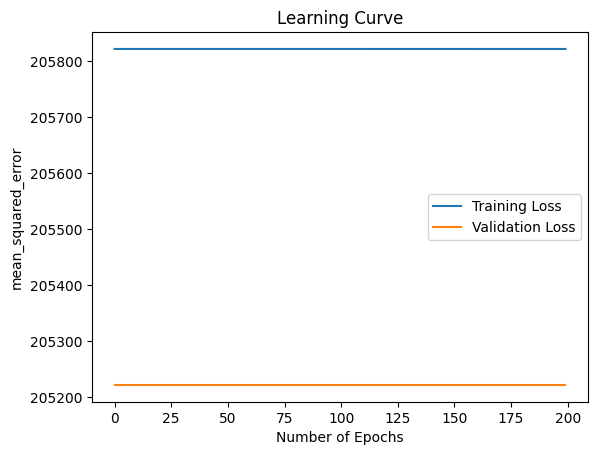

In [26]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.xlabel("Number of Epochs")
plt.ylabel("mean_squared_error")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [32]:
model.evaluate(xtest,ytest)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 206109.2969 - mean_absolute_error: 453.6641


[206109.296875, 453.6640930175781]

In [30]:
# Predictions
y_pred = model.predict(xtest)

Test MAE: 453.66 MW
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [33]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse_te = mean_squared_error(ytest,y_pred)
mae_te = mean_absolute_error(ytest,y_pred)
rmse_te = mse_te**(1/2)
r2_te = r2_score(ytest,y_pred)

print("==========================")
print("Testing Scores")
print(f"MSE:{mse_te}")
print(f"RMSE:{rmse_te}")
print(f"MAE:{mae_te}")
print(f"R2:{r2_te}")

Testing Scores
MSE:206109.28125
RMSE:453.9926004352934
MAE:453.66400146484375
R2:-690.0243530273438
